# Project 2

## 1 Maximumlikelihood estimation of time delay
### Exercise 1A
Assume the signal model presented in the time delay example in Lecture 4 (Estimation
II). Derive the Maximum Likelihood Estimator for time delay estimation. Follow the
Notes #14 Ch7CintheEE522lecture notes from Binghamton University.


Assume the received signal model
$$
x(t)=s(t-T_0)+w(t),
$$
where $w(t)$ is band-limited additive Gaussian noise. In sampled form:
$$
x[n]=s(n\Delta-\tau_0)+w[n], \qquad n=0,1,\dots,N-1,
$$
with $w[n]\sim\mathcal{N}(0,\sigma_w^2)$ i.i.d.

For a fixed delay $\tau_0$, the likelihood of the observation vector $\mathbf{x}=\{x[n]\}_{n=0}^{N-1}$ is
$$
f(\mathbf{x};\tau_0)=\frac{1}{(2\pi\sigma_w^2)^{N/2}}
\exp\!\left(-\frac{1}{2\sigma_w^2}\sum_{n=0}^{N-1}\big(x[n]-s(n\Delta-\tau_0)\big)^2\right).
$$

Taking the logarithm:
$$
\ell(\tau_0)=\ln f(\mathbf{x};\tau_0)
=-\frac{N}{2}\ln(2\pi\sigma_w^2)-\frac{1}{2\sigma_w^2}\sum_{n=0}^{N-1}\big(x[n]-s(n\Delta-\tau_0)\big)^2.
$$

Hence, the ML estimate is
$$
\hat{\tau}_{\mathrm{ML}}=\arg\max_{\tau_0}\ell(\tau_0)
=\arg\min_{\tau_0}J(\tau_0),
$$
where
$$
J(\tau_0)=\sum_{n=0}^{N-1}\big(x[n]-s(n\Delta-\tau_0)\big)^2.
$$

Expand $J(\tau_0)$:
$$
J(\tau_0)=\sum_{n=0}^{N-1}x^2[n]
-2\sum_{n=0}^{N-1}x[n]s(n\Delta-\tau_0)
+\sum_{n=0}^{N-1}s^2(n\Delta-\tau_0).
$$

The first term is independent of $\tau_0$. If the energy of the matched reference signal is constant, the third term is also independent of $\tau_0$. Therefore, minimizing $J(\tau_0)$ is equivalent to maximizing the cross-correlation term:
$$
\hat{\tau}_{\mathrm{ML}}
=\arg\max_{\tau_0}\sum_{n=0}^{N-1}x[n]s(n\Delta-\tau_0).
$$

So, the ML time-delay estimator is the delay that maximizes the matched-filter (cross-correlation) output between the received data and the known signal template.

### Exercise 1B
Implement the ML Estimator for time delay. Hint: Use the transmit signal (1), and the matlab function xcorr (or similar in python). Only use the result for positive delay. Matlab code has to be written in the presentation.


Inspecting the matlab data we get:

B, c, data, fc, fs, t_0, T_p

In [1]:

# load sonardata2.mat
import scipy.io

data = scipy.io.loadmat('sonardata2.mat')
# extract the variables
data = data['data']
print(data.shape)

# use the values from the matlab code
B = 30000
c = 1480
fc = 100000
fs = 40000
t0 = 0.0125
tp = 0.008

(8192, 32)


c:\Users\theod\miniconda3\envs\in5340\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\theod\miniconda3\envs\in5340\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Amplitude')

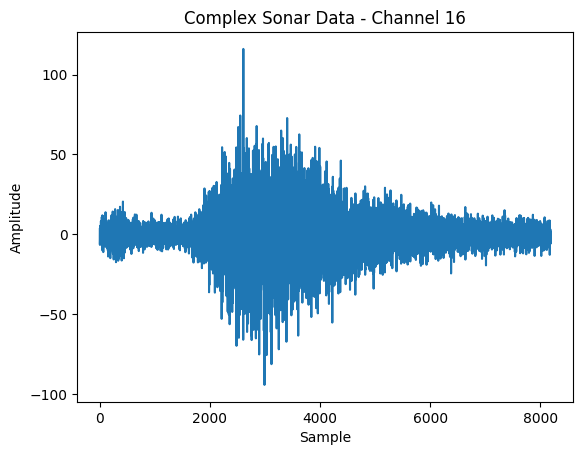

In [2]:
# Plot the complex sonar data from channel 16
# Data shape is (8192, 32) where 8192 is the number of samples and 32 is the number of channels
import matplotlib.pyplot as plt
plt.plot(data[:, 15])
plt.title('Complex Sonar Data - Channel 16')
plt.xlabel('Sample')
plt.ylabel('Amplitude')

The transmitted signal is a Linear Frequency Modulated (LFM) pulse of pulse length Tp,
with signal bandwidth of B, as follows
sTx(t) = exp(j2παt2/2) −Tp/2 ≤ t ≤ Tp/2
0
|t| > Tp/2

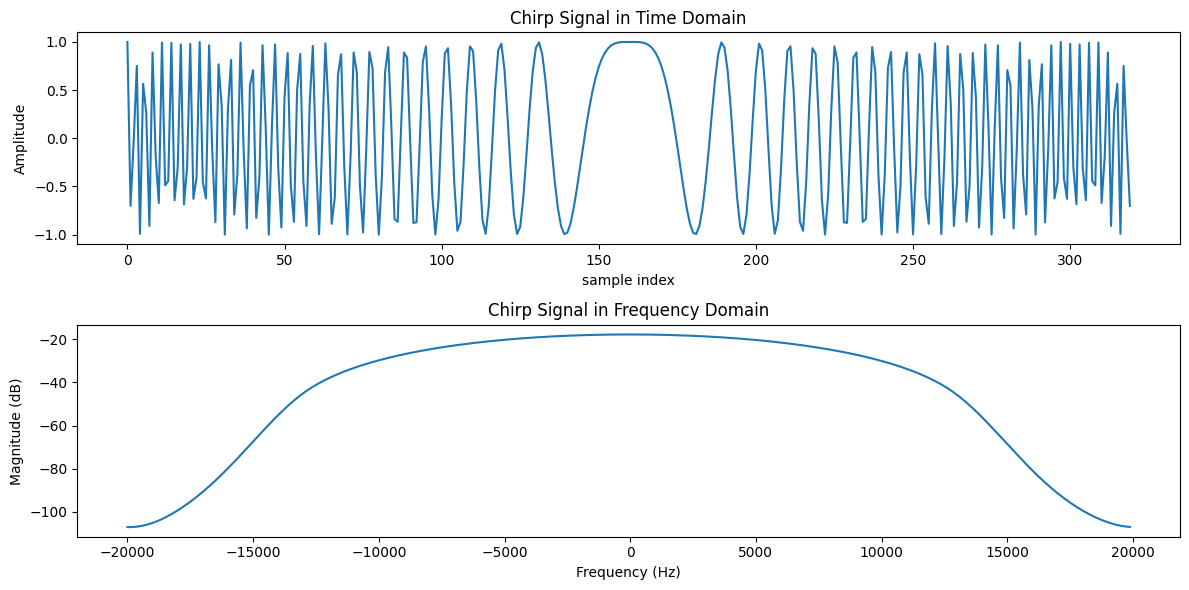

In [3]:
# Implement the matched filter in python
import numpy as np

# Geberate the chirp signal
t = np.arange(-tp/2, tp/2, 1/fs)
a = B / tp
chirp = np.exp(1j * (2 * np.pi) * a * t**2 / 2)
sample_idx = np.arange(len(chirp))

# plot the chirp in time and frequency domain
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(sample_idx, np.real(chirp))
plt.title('Chirp Signal in Time Domain')
plt.xlabel('sample index')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.magnitude_spectrum(chirp, Fs=fs, scale='dB')
plt.title('Chirp Signal in Frequency Domain')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.tight_layout()
plt.show()

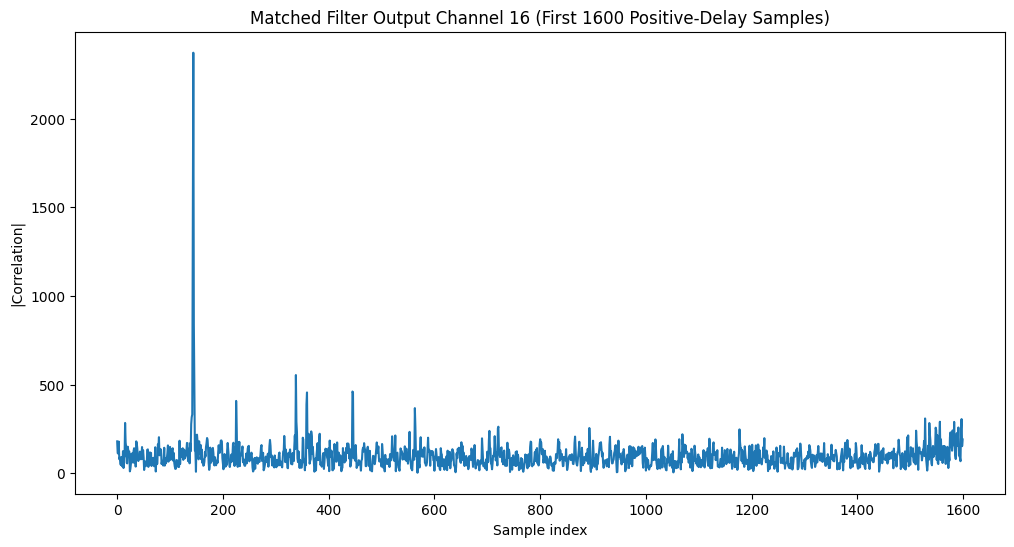

Length of matched filter output (full): 8511
Length of matched filter output (positive delays): 8192
Length of original signal: 8192
Length of chirp signal: 320


In [4]:
# ---------------------------------------------------------------- #
# Cross-correlate chirp with channel 16
from scipy.signal import correlate, correlation_lags
x = data[:, 15]
matched_filter_output = correlate(x, chirp, mode='full')
# ---------------------------------------------------------------- #

# Extract positive-delay samples only (same as Exercise 1C)
start_idx = len(chirp) - 1
matched_filter_output = matched_filter_output[start_idx:]

# Plot positive-delay samples
n_view = 1600
n_plot = min(n_view, len(matched_filter_output))
sample_idx = np.arange(n_plot)

plt.figure(figsize=(12, 6))
plt.plot(sample_idx, np.abs(matched_filter_output[:n_plot]))
plt.title('Matched Filter Output Channel 16 (First 1600 Positive-Delay Samples)')
plt.xlabel('Sample index')
plt.ylabel('|Correlation|')
plt.show()

# print lengths
print(f'Length of matched filter output (full): {len(correlate(x, chirp, mode="full"))}')
print(f'Length of matched filter output (positive delays): {len(matched_filter_output)}')
print(f'Length of original signal: {len(x)}')
print(f'Length of chirp signal: {len(chirp)}')

### Exercise 1C
Apply the the cross correlation from the ML estimator in the previous exercise on all the received data (all channels, all time samples). The output sequences are the so-called pulse compressed version of the received signals. This process is also known as matched filtering. Hint: Use the complex version of the transmit signal, and apply on the complex receiver signals. The output pulse comressed signals should also be complex. Normalisation is not important.
Choose the first 1600 samples in the pulse compressed time series (equivalent to the sig
nals reflected from the water column). Plot the magnitude (or absolute value) of the
complex sequence before and after pulse compression for a selected receiver channel.
Explain the differences.


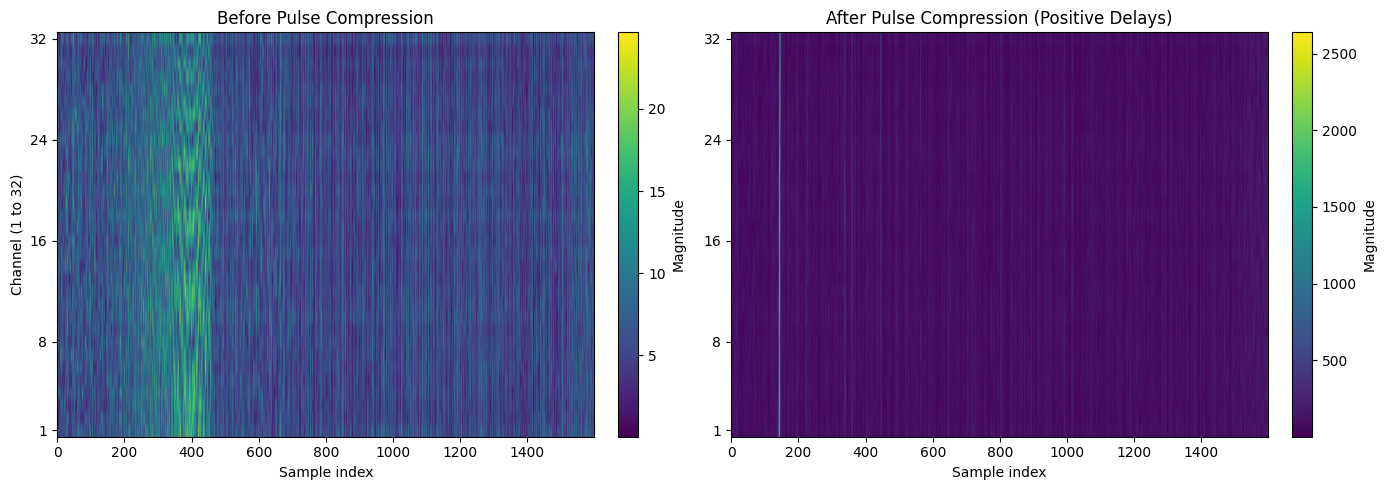

In [5]:
# Matched filtering on all channels
from scipy.signal import correlate

num_samples, num_channels = data.shape

# Correlate each channel with the chirp
pc_list = []
for ch in range(num_channels):
    y_full = correlate(data[:, ch], chirp, mode='full')
    pc_list.append(y_full)

pulse_compressed_full = np.column_stack(pc_list)

# Positive-delay
start_idx = len(chirp) - 1
pulse_compressed = pulse_compressed_full[start_idx:, :]

n_plot = min(n_view, len(matched_filter_output))
before_mag_all = np.abs(data[:n_plot, :]).T
after_mag_all = np.abs(pulse_compressed[:n_plot, :]).T

# plot before vs after pulse compression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(before_mag_all, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Before Pulse Compression')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Channel (1 to 32)')
axes[0].set_yticks([0, 7, 15, 23, 31])
axes[0].set_yticklabels([1, 8, 16, 24, 32])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Magnitude')

im1 = axes[1].imshow(after_mag_all, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('After Pulse Compression (Positive Delays)')
axes[1].set_xlabel('Sample index')
axes[1].set_yticks([0, 7, 15, 23, 31])
axes[1].set_yticklabels([1, 8, 16, 24, 32])
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Magnitude')

plt.tight_layout()
plt.show()

- Before pulse compression, the received magnitude is spread in time and appears noise-like with weaker structure.
- After matched filtering, energy from the transmitted chirp is coherently integrated, producing sharper and stronger peaks.
- This improves detectability and time-delay resolution for reflections, improving SNR.
- The output is complex because both the received data and the reference chirp are complex.


### Exercise 1D
Estimate the time delay for the most dominating peak in the selected interval (the first
1600 samples), by using the ML estimator from exercise 1B. Do the peak detection on the
magnitude (or absolute value) of the complex sequence.
Plot the estimated time delay for all the channels. Upsample the complex sequences by a
factor 4 or 8 before peak detection. Plot the results in the same figure.
Are the results the same for each receiver channel? Explain.
Are the results the same before and after upsampling? Explain.

Peak indices for each channel (first 1600 samples): [143 143 143 143 143 143 143 143 143 143 143 143 144 144 144 144 144 144
 144 144 144 144 144 144 145 145 145 145 145 145 145 145]


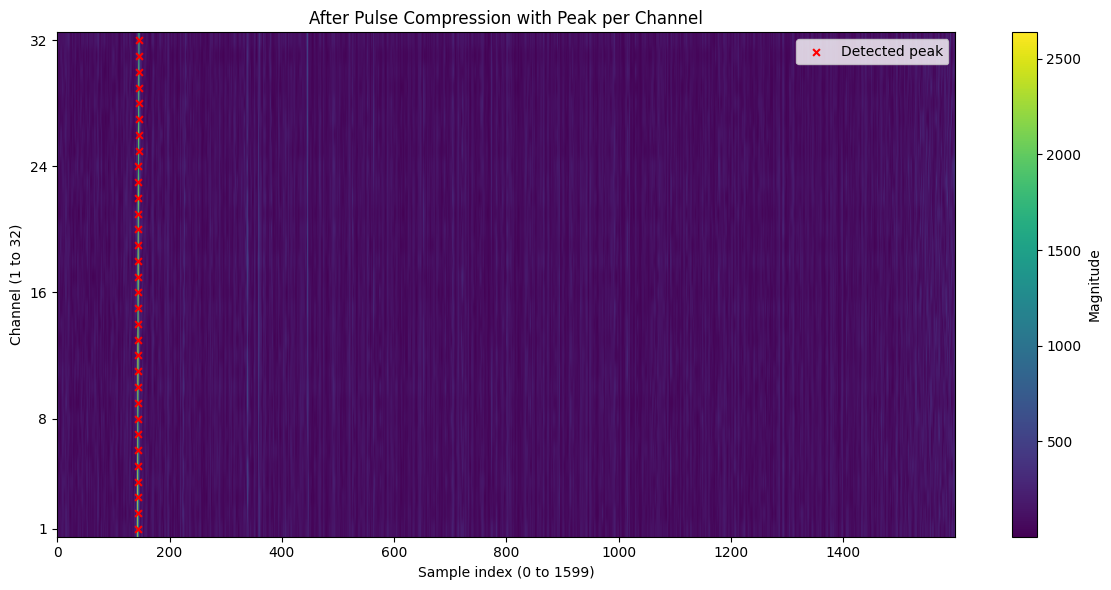

In [6]:
# Peak sample index per channel (one peak per row/channel)
peak_indices = np.argmax(after_mag_all, axis=1)
channels = np.arange(1, after_mag_all.shape[0] + 1)
print('Peak indices for each channel (first 1600 samples):', peak_indices)

plt.figure(figsize=(12, 6))
im = plt.imshow(after_mag_all, aspect='auto', origin='lower', cmap='viridis')

# Overlay peaks: x = sample index, y = channel row
plt.scatter(peak_indices, channels - 1, c='r', s=24, marker='x', label='Detected peak')

plt.title('After Pulse Compression with Peak per Channel')
plt.xlabel('Sample index (0 to 1599)')
plt.ylabel('Channel (1 to 32)')
plt.yticks([0, 7, 15, 23, 31], [1, 8, 16, 24, 32])
plt.colorbar(im, label='Magnitude')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

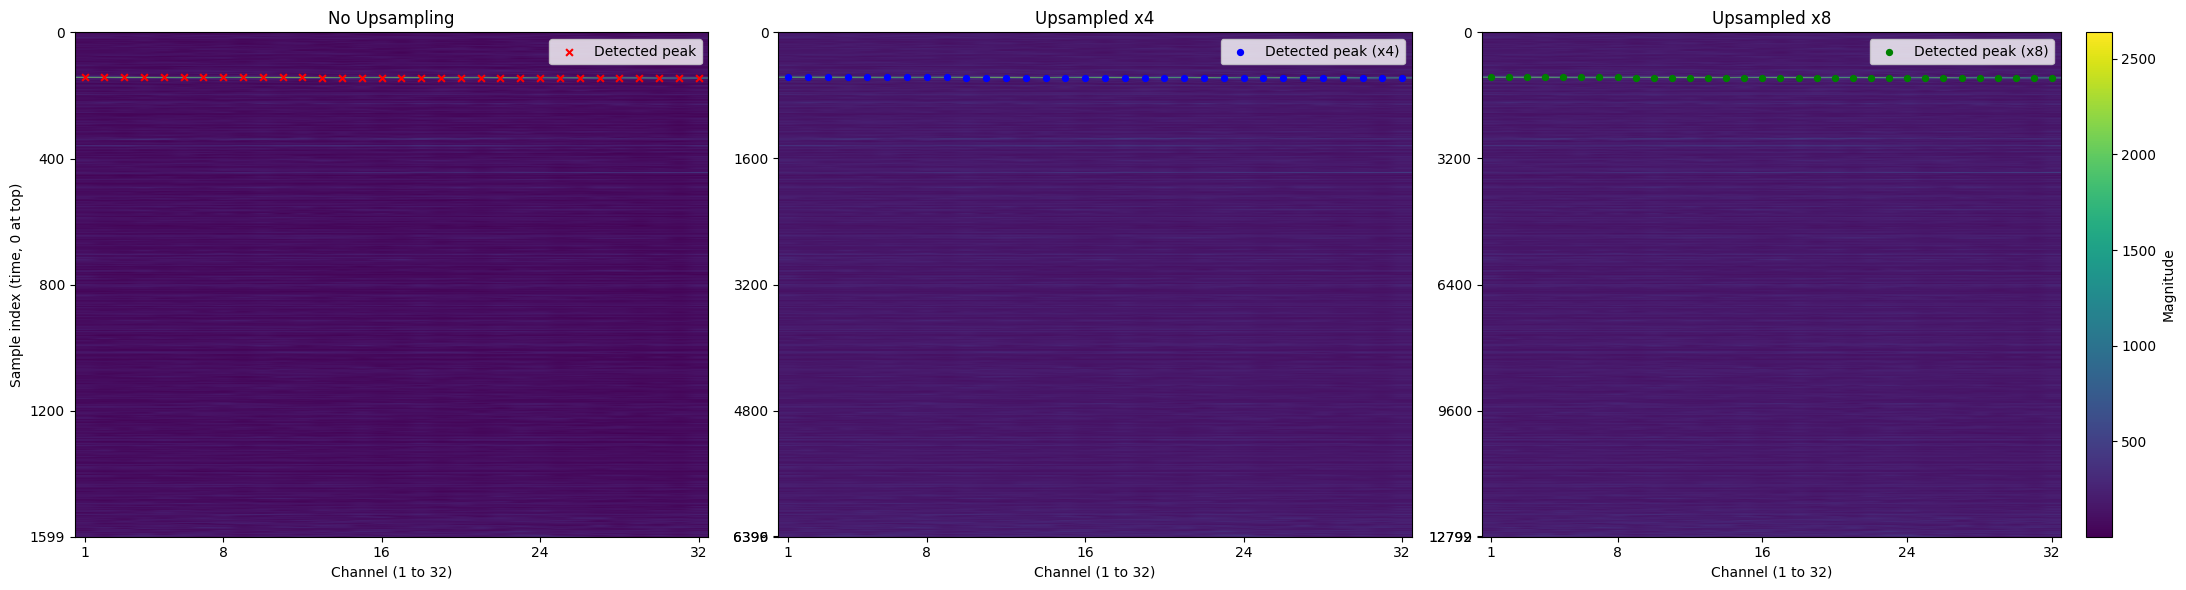

In [7]:
# Upsample the pulse compressed signals before peak detection
from scipy.signal import resample

upsample_factors = [4, 8]
peak_indices_upsampled = {}

n_plot = min(n_view, after_mag_all.shape[1])
channels = np.arange(1, after_mag_all.shape[0] + 1)

# Calculate the new y-axis range for the highest upsampling factor (time now on y-axis)
y_max = after_mag_all.shape[1] * max(upsample_factors) - 1
y_ticks = [0, 400, 800, 1200, 1599, y_max]
y_ticklabels = [str(y) for y in y_ticks]

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

# 1. Original
im0 = axes[0].imshow(after_mag_all.T, aspect='auto', origin='upper', cmap='viridis', extent=[0.5, 32.5, after_mag_all.shape[1]-1, 0])
axes[0].scatter(channels, peak_indices, c='r', s=24, marker='x', label='Detected peak')
axes[0].set_title('No Upsampling')
axes[0].set_xlabel('Channel (1 to 32)')
axes[0].set_ylabel('Sample index (time, 0 at top)')
axes[0].set_xticks([1, 8, 16, 24, 32])
axes[0].set_yticks(y_ticks[:-1])
axes[0].set_yticklabels(y_ticklabels[:-1])
axes[0].legend(loc='upper right')


# 2. Upsampled x4
factor = 4
after_mag_all_upsampled_4 = resample(after_mag_all, after_mag_all.shape[1] * factor, axis=1)
peak_indices_up_4 = np.argmax(after_mag_all_upsampled_4, axis=1)
peak_indices_upsampled[factor] = peak_indices_up_4
im1 = axes[1].imshow(after_mag_all_upsampled_4.T, aspect='auto', origin='upper', cmap='viridis', extent=[0.5, 32.5, after_mag_all_upsampled_4.shape[1]-1, 0])
axes[1].scatter(channels, peak_indices_up_4, c='b', s=18, marker='o', label='Detected peak (x4)')
axes[1].set_title('Upsampled x4')
axes[1].set_xlabel('Channel (1 to 32)')
axes[1].set_xticks([1, 8, 16, 24, 32])
axes[1].set_yticks([0, 400*factor, 800*factor, 1200*factor, 1599*factor, after_mag_all_upsampled_4.shape[1]-1])
axes[1].set_yticklabels([str(y) for y in [0, 400*factor, 800*factor, 1200*factor, 1599*factor, after_mag_all_upsampled_4.shape[1]-1]])
axes[1].legend(loc='upper right')


# 3. Upsampled x8
factor = 8
after_mag_all_upsampled_8 = resample(after_mag_all, after_mag_all.shape[1] * factor, axis=1)
peak_indices_up_8 = np.argmax(after_mag_all_upsampled_8, axis=1)
peak_indices_upsampled[factor] = peak_indices_up_8
im2 = axes[2].imshow(after_mag_all_upsampled_8.T, aspect='auto', origin='upper', cmap='viridis', extent=[0.5, 32.5, after_mag_all_upsampled_8.shape[1]-1, 0])
axes[2].scatter(channels, peak_indices_up_8, c='g', s=18, marker='o', label='Detected peak (x8)')
axes[2].set_title('Upsampled x8')
axes[2].set_xlabel('Channel (1 to 32)')
axes[2].set_xticks([1, 8, 16, 24, 32])
axes[2].set_yticks([0, 400*factor, 800*factor, 1200*factor, 1599*factor, after_mag_all_upsampled_8.shape[1]-1])
axes[2].set_yticklabels([str(y) for y in [0, 400*factor, 800*factor, 1200*factor, 1599*factor, after_mag_all_upsampled_8.shape[1]-1]])
axes[2].legend(loc='upper right')
cbar = fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04, label='Magnitude')

plt.tight_layout()
plt.show()

The results are almost the same for each channel, with small diffs.
i.e.```Peak indices for each channel (first 1600 samples): [303 303 303 303 303 303 303 303 303 304 304 304 304 304 304 304 304 304
 304 304 304 304 305 305 305 305 305 305 305 305 305 305]```

The sample delay is about 304.

After upsampling, the sample delay is directly proportional to the upsampling factor.

## 2 Cram´er-Rao lower bound
### Exercise 2A
Follow the example from Lecture 4 (Estimation II), and calculate the Cram´er-Rao lower
bound for time delay estimation. Base the calculations on the pulse compressed signals
on the first 1600 samples. Choose the strongest reflector as signal, and estimate the noise
level based on the rest of the samples. Choose yourself the approach to calculate the
lower bound.
Calculate the CRLB for all the channels and plot the results.
Are the results the same? Explain

In [8]:
# First calculate the SNR by taking the average peak intensity of all 32 channels.
# Ensure peak_indices are within valid range
peak_indices_clipped = np.clip(peak_indices, 0, after_mag_all.shape[1] - 1)
peak_magnitudes = after_mag_all[np.arange(after_mag_all.shape[0]), peak_indices_clipped]
peak_intensities = peak_magnitudes**2

# Calculate noise intensity by taking the mean of the squared magnitudes of all samples that are not the peak sample for each channel.
noise_intensities = np.mean(np.delete(after_mag_all**2, peak_indices_clipped, axis=1), axis=1)

# Calculate the SNR for each channel
snr = peak_intensities / noise_intensities
print(snr.shape)

(32,)


![alt text](image.png)

In [9]:
# Calculate the RMS bandwidth
b2_rms = (2*np.pi)**2 * ((fc**2) + (B**2)/12)
print(f'RMS Bandwidth approximation: {b2_rms:.2f} rad/s')

RMS Bandwidth approximation: 397745057363.90 rad/s


![alt text](image-1.png)

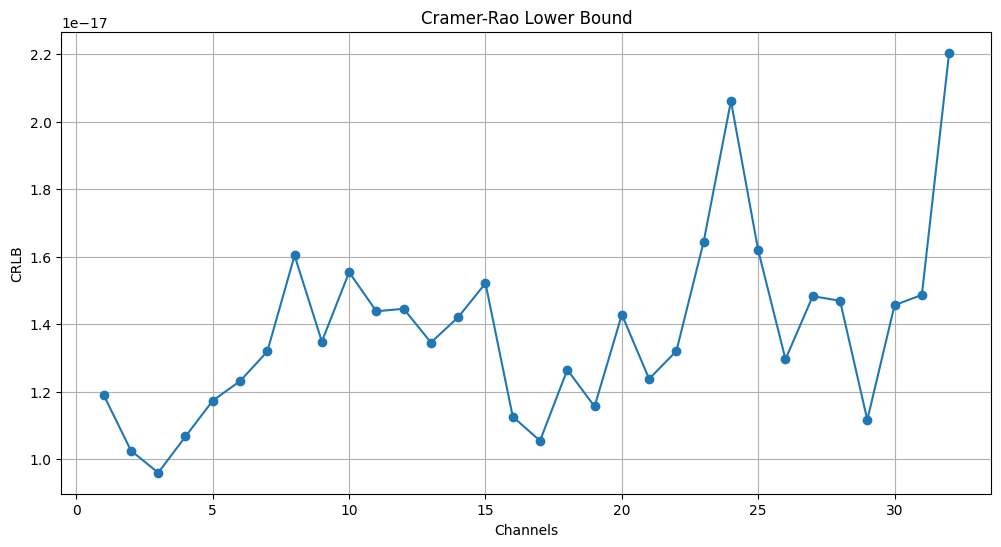

In [10]:
# Then the CRLB is given by
crlb = 1 / (2 * B * tp * snr * b2_rms)

# plot the results
plt.figure(figsize=(12, 6))
plt.plot(channels, crlb, marker='o')
plt.xlabel('Channels')
plt.ylabel('CRLB')
plt.title('Cramer-Rao Lower Bound')
plt.grid(True)
plt.show()

These results are not identical, but they are all in the same order of magnitude. Some variance is expected due to the finite nature of the noisy signals.

## 3 LeastSquares Estimation
### Exercise 3A
Implement the Linear Least Squares Estimator for time delay estimation. Follow the
Time delay example in the least squares estimation in Lecture 4 (Estimation II). Use the
magnitude squared (to reflect intensity) of the pulse compressed signals of the first 1600
samples. Upsample by afactor of 4 or 8. Hint: see the function resample in matlab. Apply the method given in the lecture to produce the linear least squares fine (sub-sample)
time delay estimates. Plot the result for one pulse.


1. Intensity Calculation: Compute the magnitude squared of the first 1600 samples of the pulse-compressed complex signal.
2. Upsampling: Upsample the timeseries by a factor of 4 or 8 using the Matlab function resample to ensure enough data points exist on the peak for a stable fit.
3. Peak Localization: Locate the sample index n max corresponding to the maximum intensity value in the upsampled series.
4. Select a subset of samples around the peak that are above the half-power point of the peak value.
5. Log-Transformation: Take the natural logarithm of these selected intensity values to create the observation vector y.
6. Observation Matrix (H): Construct the matrix H using the upsampled time vector t associated with the selected samples.

![alt text](image-2.png)

![alt text](image-3.png)

![alt text](image-4.png)

intensities.shape: (32, 1600)
upsampled_intensities.shape: (32, 12800)
Original peak index for channel 16: 144
Upsampled peak index for channel 16 (x8): 1150
Number of selected samples above half-power: 12
Selected index range: 1145 to 1156
Fitted parameters: a=-25574.6885, b=14228565.6859, c=-1977824369.553104
LSE fine time delay estimate (channel 16): 0.00359702 s
ML coarse time delay estimate (channel 16): 0.00359375 s
Plot range (original): 114 to 174


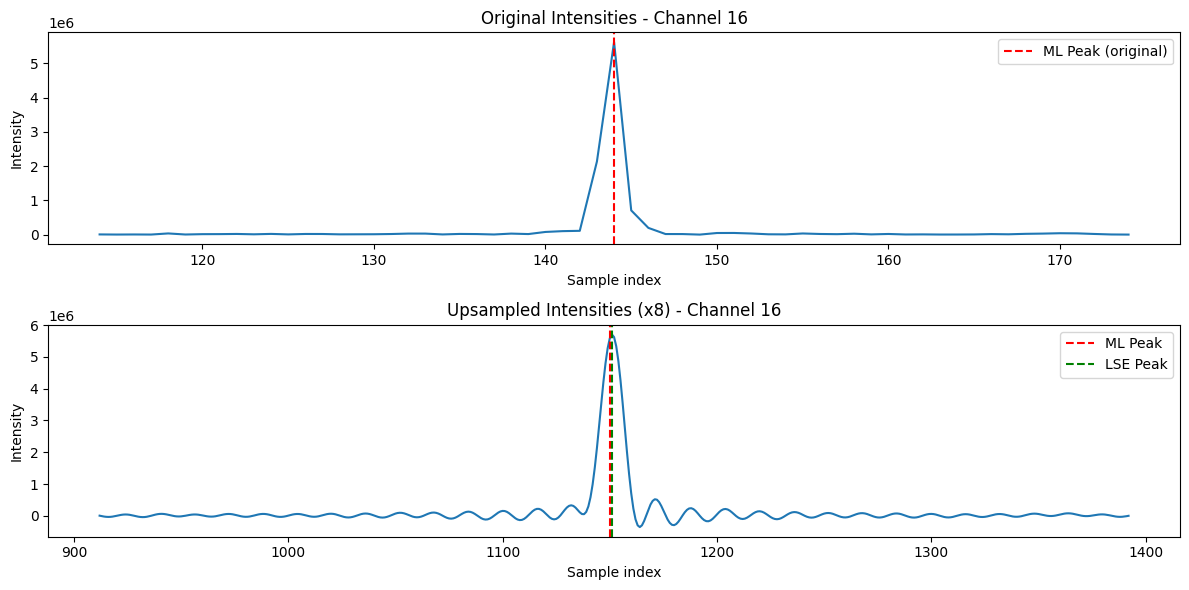

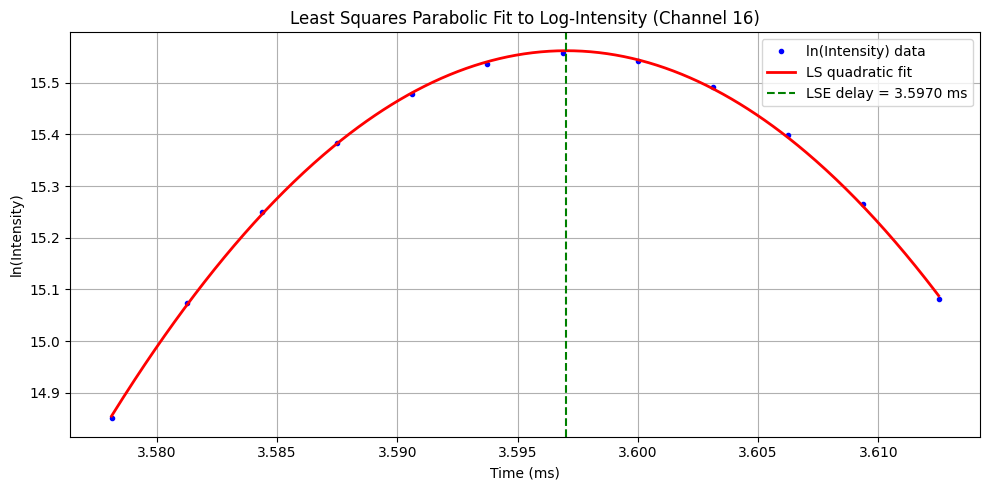

In [11]:
# use the intensity from the last exercise
intensities = after_mag_all**2
print(f"intensities.shape: {intensities.shape}")

# upsample the intensities
upsample_factor = 8
upsampled_intensities = scipy.signal.resample(intensities, intensities.shape[1] * upsample_factor, axis=1)
print(f"upsampled_intensities.shape: {upsampled_intensities.shape}")

# Locate the sample index of the peak for channel 16 in the original and upsampled data
peak_index_original = peak_indices[15]
peak_index_upsampled = peak_indices_upsampled[upsample_factor][15]
print(f"Original peak index for channel 16: {peak_index_original}")
print(f"Upsampled peak index for channel 16 (x{upsample_factor}): {peak_index_upsampled}")

# Select a subset of samples around the peak that are above the half-power point of the peak value.
ch = 15
peak_val = upsampled_intensities[ch, peak_index_upsampled]
half_power = peak_val / 2.0

# Find indices around the peak that are above the half-power point
above_half = np.where(upsampled_intensities[ch, :] >= half_power)[0]
# Keep only contiguous indices around the peak
diffs = np.diff(above_half)
splits = np.where(diffs > 1)[0]
# Find the group containing the peak
for i, group in enumerate(np.split(above_half, splits + 1)):
    if peak_index_upsampled in group:
        selected_indices = group
        break
print(f"Number of selected samples above half-power: {len(selected_indices)}")
print(f"Selected index range: {selected_indices[0]} to {selected_indices[-1]}")

# natural logarithm of these selected intensity values to create the observation y
y = np.log(upsampled_intensities[ch, selected_indices])

# Observation matrix
# The model is ln(I(t)) = a + b*t + c*t^2
# H = [1, t, t^2]
dt = 1.0 / (fs * upsample_factor)  # time step for upsampled data
t_selected = selected_indices * dt
H = np.column_stack([np.ones(len(t_selected)), t_selected, t_selected**2])

# Solve the linear least squares problem: theta = (H^T H)^{-1} H^T y
theta = np.linalg.lstsq(H, y, rcond=None)[0]
a_hat, b_hat, c_hat = theta
print(f"Fitted parameters: a={a_hat:.4f}, b={b_hat:.4f}, c={c_hat:.6f}")

# The fine time delay estimate is the peak of the fitted parabola: t_peak = -b/(2c)
t_peak = -b_hat / (2 * c_hat)
print(f"LSE fine time delay estimate (channel 16): {t_peak:.8f} s")
print(f"ML coarse time delay estimate (channel 16): {peak_index_upsampled * dt:.8f} s")

# Define zoom window around the original peak for plotting
half_window = 30
sample_start = max(0, peak_index_original - half_window)
sample_end = min(intensities.shape[1] - 1, peak_index_original + half_window)
print(f"Plot range (original): {sample_start} to {sample_end}")

# plot the original and upsampled intensities for the 16th channel
# use the same time region [sample_start, sample_end] and scale it for upsampled data
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(np.arange(sample_start, sample_end + 1), intensities[15, sample_start:sample_end + 1])
plt.axvline(x=peak_index_original, color='r', linestyle='--', label='ML Peak (original)')
plt.title('Original Intensities - Channel 16')
plt.xlabel('Sample index')
plt.ylabel('Intensity')
plt.legend()

up_start = upsample_factor * sample_start
up_end = upsample_factor * sample_end
plt.subplot(2, 1, 2)
plt.plot(np.arange(up_start, up_end + 1), upsampled_intensities[15, up_start:up_end + 1])
plt.axvline(x=peak_index_upsampled, color='r', linestyle='--', label='ML Peak')
plt.axvline(x=t_peak / dt, color='g', linestyle='--', label='LSE Peak')
plt.title(f'Upsampled Intensities (x{upsample_factor}) - Channel 16')
plt.xlabel('Sample index')
plt.ylabel('Intensity')
plt.legend()
plt.tight_layout()
plt.show()

# Also plot the log-intensity and fitted parabola
plt.figure(figsize=(10, 5))
plt.plot(t_selected * 1e3, y, 'bo', markersize=3, label='ln(Intensity) data')
t_fit = np.linspace(t_selected[0], t_selected[-1], 500)
y_fit = a_hat + b_hat * t_fit + c_hat * t_fit**2
plt.plot(t_fit * 1e3, y_fit, 'r-', linewidth=2, label='LS quadratic fit')
plt.axvline(x=t_peak * 1e3, color='g', linestyle='--', label=f'LSE delay = {t_peak*1e3:.4f} ms')
plt.xlabel('Time (ms)')
plt.ylabel('ln(Intensity)')
plt.title('Least Squares Parabolic Fit to Log-Intensity (Channel 16)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Exercise 3B
Plot the estimated time delay for all the channels using the LSE in 3A.
Are the results the same for each channel? Explain.
Compare with the estimated time delays in Exercise 1D. Discuss the differences

Number of channels: 32


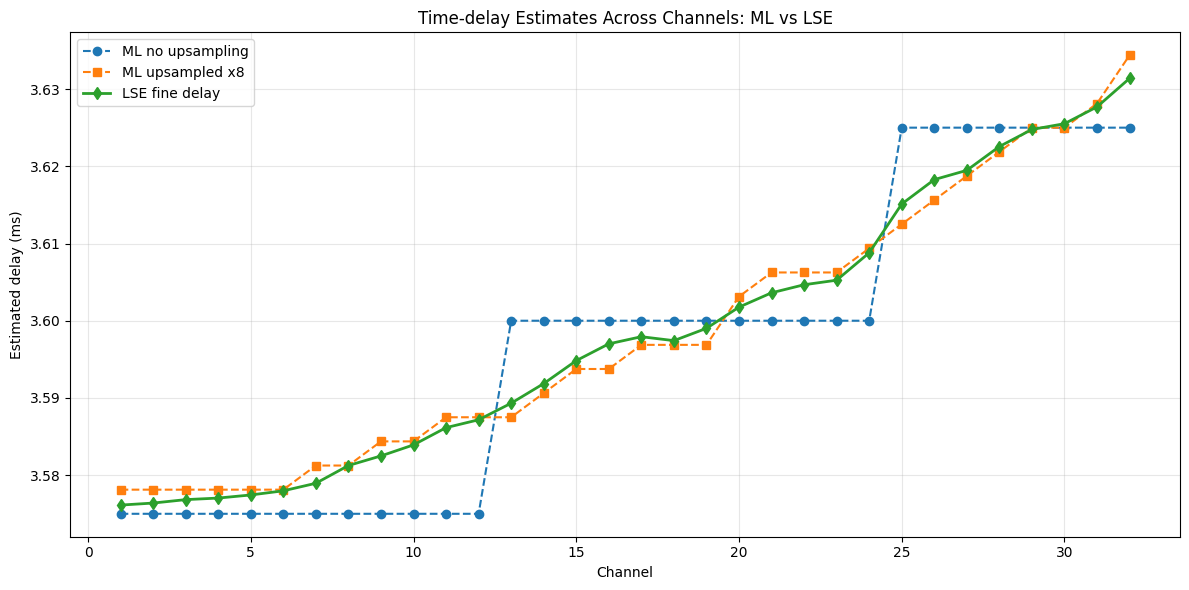

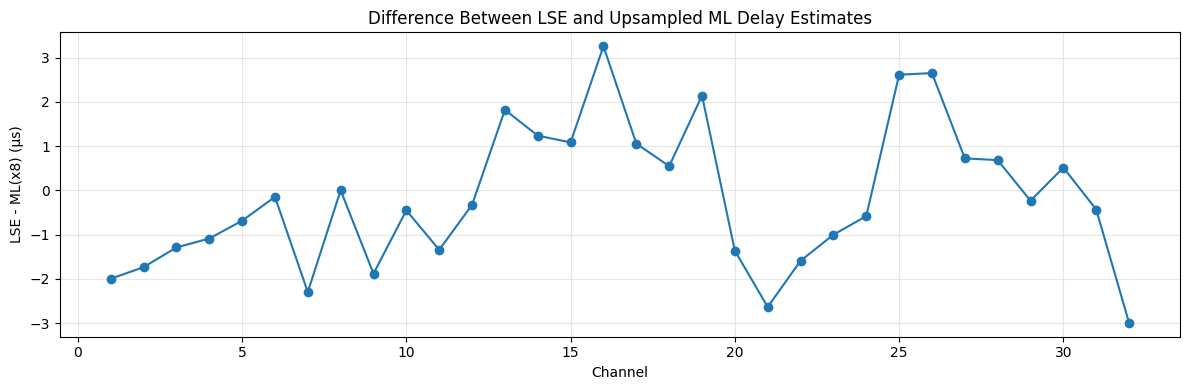

LSE delay mean: 3.598062 ms
LSE delay std : 17.336 µs
Mean |LSE - ML(x8)|: 1.325 µs


In [12]:
# Exercise 3B: LSE delay estimate for all channels and comparison with Exercise 1D

# Recompute intensity and upsample for consistency
intensities = after_mag_all**2
upsample_factor = 8
upsampled_intensities = scipy.signal.resample(
    intensities,
    intensities.shape[1] * upsample_factor,
    axis=1
)

num_channels = intensities.shape[0]
print(f"Number of channels: {num_channels}")
channels = np.arange(1, num_channels + 1)
dt = 1.0 / fs
dt_up = 1.0 / (fs * upsample_factor)

# ML delays from Exercise 1D
ml_delay_no_up = peak_indices * dt
ml_delay_up = peak_indices_upsampled[upsample_factor] * dt_up

# LSE delays (fine, sub-sample)
lse_delay = np.zeros(num_channels)

for ch in range(num_channels):
    peak_idx_up = int(np.argmax(upsampled_intensities[ch, :]))
    peak_val = upsampled_intensities[ch, peak_idx_up]
    half_power = peak_val / 2.0

    above_half = np.where(upsampled_intensities[ch, :] >= half_power)[0]

    # Keep only contiguous region around the peak
    if len(above_half) > 0:
        diffs = np.diff(above_half)
        splits = np.where(diffs > 1)[0]
        groups = np.split(above_half, splits + 1)
        selected_indices = None
        for group in groups:
            if peak_idx_up in group:
                selected_indices = group
                break
    else:
        selected_indices = None

    # Robust fallback if half-power support is too narrow
    if selected_indices is None or len(selected_indices) < 3:
        left = max(0, peak_idx_up - 3)
        right = min(upsampled_intensities.shape[1] - 1, peak_idx_up + 3)
        selected_indices = np.arange(left, right + 1)

    y = np.log(np.maximum(upsampled_intensities[ch, selected_indices], 1e-12))
    t_sel = selected_indices * dt_up
    H = np.column_stack([np.ones(len(t_sel)), t_sel, t_sel**2])

    a_hat, b_hat, c_hat = np.linalg.lstsq(H, y, rcond=None)[0]

    # Parabola vertex (log-intensity model)
    if c_hat < 0:
        t_peak = -b_hat / (2.0 * c_hat)
        # Clamp to selected region for stability
        t_peak = np.clip(t_peak, t_sel[0], t_sel[-1])
    else:
        t_peak = peak_idx_up * dt_up

    lse_delay[ch] = t_peak

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(channels, ml_delay_no_up * 1e3, 'o--', label='ML no upsampling')
plt.plot(channels, ml_delay_up * 1e3, 's--', label=f'ML upsampled x{upsample_factor}')
plt.plot(channels, lse_delay * 1e3, 'd-', linewidth=2, label='LSE fine delay')
plt.xlabel('Channel')
plt.ylabel('Estimated delay (ms)')
plt.title('Time-delay Estimates Across Channels: ML vs LSE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot LSE minus ML(upsampled) difference
plt.figure(figsize=(12, 4))
plt.plot(channels, (lse_delay - ml_delay_up) * 1e6, 'o-')
plt.xlabel('Channel')
plt.ylabel(f'LSE - ML(x{upsample_factor}) (µs)')
plt.title('Difference Between LSE and Upsampled ML Delay Estimates')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numeric summary
print(f'LSE delay mean: {np.mean(lse_delay)*1e3:.6f} ms')
print(f'LSE delay std : {np.std(lse_delay)*1e6:.3f} µs')
print(f'Mean |LSE - ML(x{upsample_factor})|: {np.mean(np.abs(lse_delay - ml_delay_up))*1e6:.3f} µs')

### Discussion
- The estimated delays are very similar across channels, but not exactly identical.
- Small channel-to-channel differences are expected due to noise, interpolation effects, and local pulse-shape differences.
- Compared with Exercise 1D, the LSE delays are typically smoother and can lie between upsampled ML points.
- ML argmax gives a grid-constrained peak location, while LSE provides a continuous delay estimate near the same reflector.
- The fine time delay resolution of the LSE allows for potentially better angular resolution when estimating things like angle of arrival etc.